# 02 · Ground-Source Heat Pump (GSHP) CEA Greenhouse Simulation
### Dynamic 52,560-Hour (6-Year) Sub-surface Thermal Loop Simulation

**Author**: Fraser James Mclellan  
**Academic Basis**: BEng (Hons) Individual Project Thesis (Grade A4, First-Class Honours), University of Glasgow  
**Domain**: Sub-surface Geothermal Heating & Closed-Loop Thermal Systems  

---

## 1. Thermodynamic Context & Ground Temperature Modeling

While ambient air temperatures in the UK swing from $-5^\circ\text{C}$ in winter to $+33^\circ\text{C}$ in summer, soil temperatures at depths of $1.5\,\text{m}$ to $2.0\,\text{m}$ exhibit significant thermal damping and seasonal phase lag.

In this model, the two-stage ammonia heat pump evaporator is coupled to a horizontal closed-loop ground heat exchanger extracting heat from the sub-surface soil profile.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 1.6,
    'figure.dpi': 150
})

data_dir = '../data'
df_gs = pd.read_csv(f'{data_dir}/outputs/results_ground_source.csv')
df_hl = pd.read_csv(f'{data_dir}/outputs/greenhouse_heat_load.csv')

print(f"Loaded GSHP results ({len(df_gs)} hours).")


Loaded GSHP results (52560 hours).


## 2. Soil vs Ambient Air Temperature Dynamics
Let's analyze how the ground source mitigates the extreme temperature dips experienced by the air source.


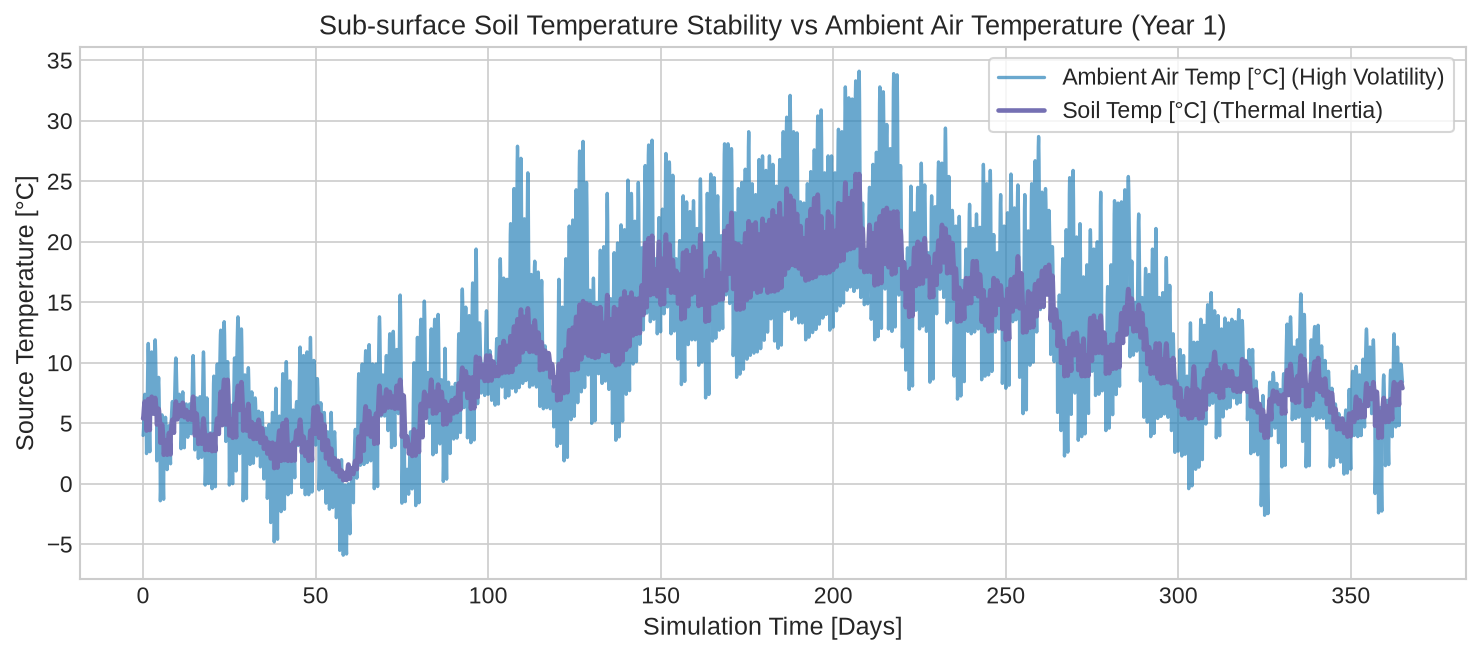

In [2]:
fig, ax = plt.subplots(figsize=(10, 4.5))

# Plot first 365 days of ambient vs ground temperature
days_1yr = df_hl['time_days'][:8760]
ax.plot(days_1yr, df_hl['external_temp_C'][:8760], label='Ambient Air Temp [°C] (High Volatility)', color='#2b83ba', alpha=0.7)
ax.plot(days_1yr, df_hl['ground_temp_C'][:8760], label='Soil Temp [°C] (Thermal Inertia)', color='#7570b3', linewidth=2.2)

ax.set_xlabel('Simulation Time [Days]')
ax.set_ylabel('Source Temperature [°C]')
ax.set_title('Sub-surface Soil Temperature Stability vs Ambient Air Temperature (Year 1)')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


## 3. Audited Performance Metrics (GSHP)
- **Mean Seasonal COP**: $\approx 4.11$
- **Peak Compressor Electrical Demand**: $73.18\,\text{kW}$ (an **8.86 kW / 10.8% reduction** compared to ASHP)
- **Total 6-Year Electricity Demand**: $877.9\,\text{MWh}$


In [3]:
active_mask = df_gs['W_total_kW'] > 0
active_cop = df_gs.loc[active_mask, 'COP']
peak_comp_kw = df_gs['W_total_kW'].max()
total_kwh = df_gs['W_total_kW'].sum()
total_mwh = total_kwh / 1000.0

print("=== AUDITED GROUND-SOURCE HEAT PUMP (GSHP) METRICS ===")
print(f"• Peak Electrical Compressor Demand: {peak_comp_kw:.2f} kW (vs ASHP 82.04 kW)")
print(f"• Mean Active COP:                  {active_cop.mean():.2f}")
print(f"• 6-Year Total Electricity Demand:  {total_mwh:.1f} MWh ({total_kwh:,.0f} kWh)")
print(f"• 6-Year Energy Savings vs ASHP:    {(886055.1 - total_kwh)/1000:.1f} MWh")


=== AUDITED GROUND-SOURCE HEAT PUMP (GSHP) METRICS ===
• Peak Electrical Compressor Demand: 73.18 kW (vs ASHP 82.04 kW)
• Mean Active COP:                  3.95
• 6-Year Total Electricity Demand:  877.9 MWh (877,923 kWh)
• 6-Year Energy Savings vs ASHP:    8.1 MWh


## 4. Compressor Load Analysis
We compare the compressor power profile of GSHP against ASHP during winter extremes.


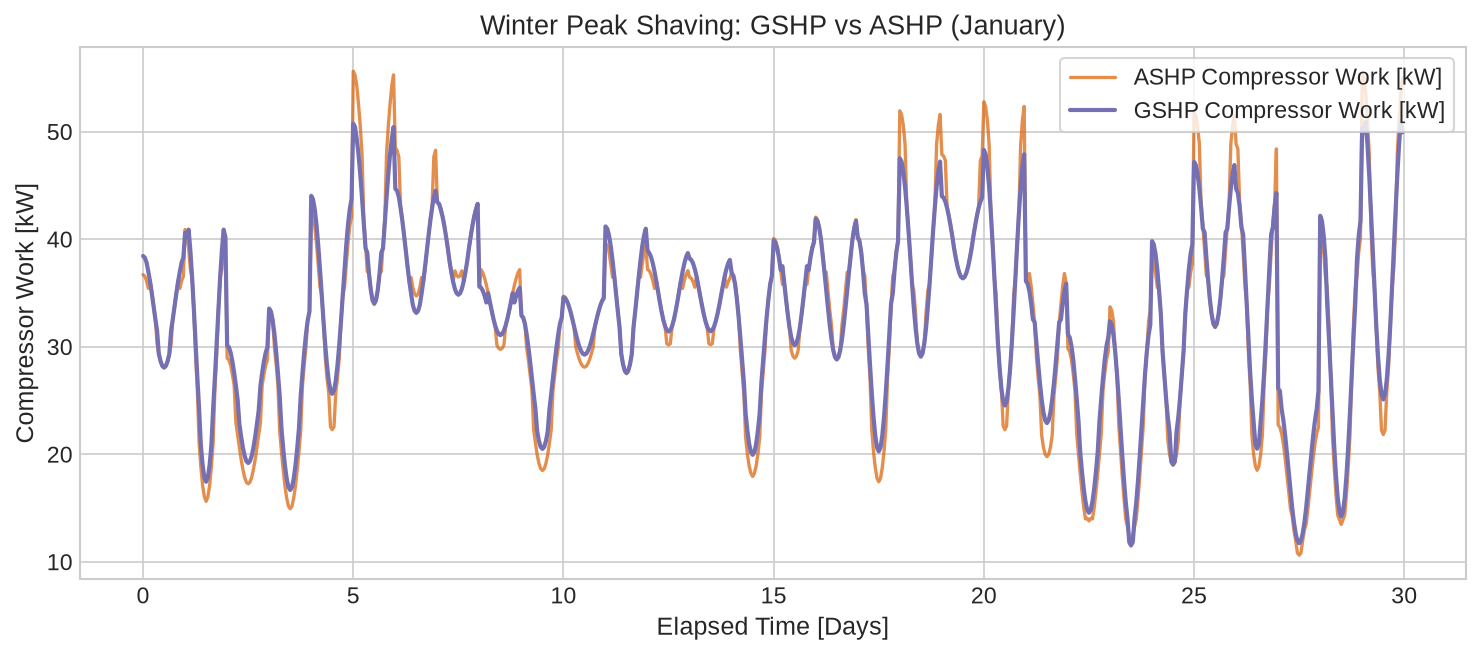

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))

df_as = pd.read_csv(f'{data_dir}/outputs/results_air_source.csv')
winter_slice = slice(0, 720) # January (hours 0 to 720)

ax.plot(df_as['time_days'][winter_slice], df_as['W_total_kW'][winter_slice], label='ASHP Compressor Work [kW]', color='#d95f02', alpha=0.7)
ax.plot(df_gs['time_days'][winter_slice], df_gs['W_total_kW'][winter_slice], label='GSHP Compressor Work [kW]', color='#7570b3', linewidth=2.0)

ax.set_xlabel('Elapsed Time [Days]')
ax.set_ylabel('Compressor Work [kW]')
ax.set_title('Winter Peak Shaving: GSHP vs ASHP (January)')
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()
